# Experiment on simulations n°3 - Curse of dimensionality: HDLSS/SSS problem (see Section 5.1.4)

## Outline

[Content](#content)

[Prerequisite packages and settings](#prerequisite-packages-and-settings)

[Step 1: Traces generation](#step-1)

[Step 2: Instanciation of a cVAE-OSM model](#step-2)

[Step 3: Training of cVAE-OSM model](#step-3)

[Step 4: Visualization of leakage models extracted by the model](#step-4)

## Content <a class='anchor' id='content'></a>

In this notebook, we propose to conduct the third experiment of our paper (see Section 5.1.4), in which we assess cVAE-OSM ability to overcome HDLSS/SSS problem.

To do so, we first generate traces such that the total number of traces per classes $N$ is lower than the number of samples $D$. 

Then, we instanciate and train a cVAE-OSM model. Finally, according to parameters estimated by our model, we assess its weights convergence.

## Prerequisite packages and settings <a class='anchor' id='prerequisite-packages-and-settings'></a>

Here are the Python packages and settings needed to run properly this notebook.

In [1]:
from cvae_osm_utils.cVAE_OSM_model import *
from cvae_osm_utils.cVAE_OSM_tools import *
from cvae_osm_utils.experiments_tools import *
from matplotlib import pyplot as plt

# Enables Tensorflow program to run deterministically for reproducible results
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

plt.rcParams['text.usetex'] = True

## Step 1: Traces generation <a class='anchor' id='step-1'></a>

The generation of traces is done using a function called $\texttt{generate\_traces\_sss\_hdlss\_experiment}$, available in $\texttt{experiments\_tools.py}$ file. 

In the following example, we generate $N=D/3$ traces per classes with $D=150$ following the fourth scenario with a isotropic Gaussian noise of parameters $\mu=0$ and $\sigma=5$. We consider $10\%$ of samples as PoIs.

We set the seed to $42$ to have reproductible results. 

In [2]:
# Traces generation
traces, plaintexts, keys, targeted_variables, sigmas = generate_traces_sss_hdlss_experiment(nb_traces_per_classes=50, nb_samples=150, nb_poi=15, mu=0, sigmas=np.array([5]), \
                        isotropic_noise=True, scenario='scenario_4', seed=42)

print("Traces generated \U00002705")

Traces generated ✅


Here is an example of generated traces.

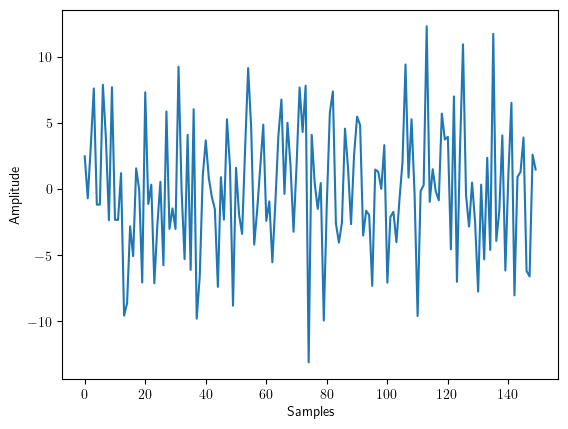

In [3]:
# Plot of a trace
plt.plot(traces[0,:])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

## Step 2: Instanciation of a cVAE-OSM model <a class='anchor' id='step-2'></a>

After generating traces, we instanciate a cVAE-OSM model. As for traces generation, to enable reproductible results, we set the seed to a fixed value. In this case, we choose $\texttt{seed}=42$.

Considering a learning rate set to $0.0001$, we instanciate a cVAE-OSM by calling $\texttt{cVAE}$ class (see $\texttt{cVAE\_OSM\_model.py}$ file) and compile the model.

In [4]:
# Instanciation of encoder and decoder
nb_samples = traces.shape[1]
learning_rate = 0.0001
max_nb_monomials_interactions, len_basis = 8, 256

encoder = define_encoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)
decoder = define_decoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)

# Instanciation of cVAE-OSM model
cVAE_OSM = cVAE(encoder, decoder)

# Compilation of cVAE-OSM model
cVAE_OSM.compile(optimizer=keras.optimizers.Adam(learning_rate))

print("Model created \U00002705")


Model created ✅


## Step 3: Training of cVAE-OSM model <a class='anchor' id='step-3'></a>

Once the model is created, we train our model using simulated traces and the projection of targeted variables into the orthonormal basis.

The projection of targeted variables onto Guilley *et al.* basis is computed using $\texttt{orthonormal\_basis\_projection}$ function, which is available in $\texttt{cVAE\_OSM\_tools.py}$ file. We consider all bits interactions, thus $\texttt{len\_basis}=256$.

In [5]:
# Projection of target variables onto Guilley etal. orthonormal basis
# We consider the full basis (len_basis=256) i.e. all the monomials len_basis=256
# One can also consider other configurations
# For example, when considering only the monomials individually i.e. without interactions between them, len_basis=9
projection_targeted_variables = orthonormal_basis_projection(targeted_variables, max_nb_monomials_interactions, len_basis)

print("Projection done \U00002705")

Projection done ✅


Then, training is done for $200$ epochs using a batch size set to $8$.

In [6]:
# cVAE-OSM training
batch_size = 4
epochs = 200

cVAE_OSM.fit([traces, projection_targeted_variables], epochs=epochs, batch_size=batch_size)

print("Training done \U00002705")

Epoch 1/200
3200/3200 [==============================] - 9s 2ms/step - ELBO loss: 24488.1356 - reconstruction_loss: 1913.2563 - kl_loss: 19487.1797
Epoch 2/200
3200/3200 [==============================] - 7s 2ms/step - ELBO loss: 13512.9447 - reconstruction_loss: 1453.6222 - kl_loss: 9988.1309
Epoch 3/200
3200/3200 [==============================] - 16s 5ms/step - ELBO loss: 6220.8407 - reconstruction_loss: 1030.4861 - kl_loss: 3926.7607
Epoch 4/200
3200/3200 [==============================] - 15s 5ms/step - ELBO loss: 2071.5332 - reconstruction_loss: 670.6642 - kl_loss: 852.6591
Epoch 5/200
3200/3200 [==============================] - 16s 5ms/step - ELBO loss: 573.6276 - reconstruction_loss: 475.5259 - kl_loss: 33.8487
Epoch 6/200
3200/3200 [==============================] - 16s 5ms/step - ELBO loss: 458.8524 - reconstruction_loss: 458.2998 - kl_loss: 0.4924
Epoch 7/200
3200/3200 [==============================] - 16s 5ms/step - ELBO loss: 458.6846 - reconstruction_loss: 458.2646 - kl

## Step 4: Visualization of leakage models extracted by the model <a class='anchor' id='step-4'></a>

Finally, we can visualize the deterministic parts estimated by our model *i.e.* $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$, and compare them to the true leakage model.

This visualization is done using $\texttt{weights\_visualization}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

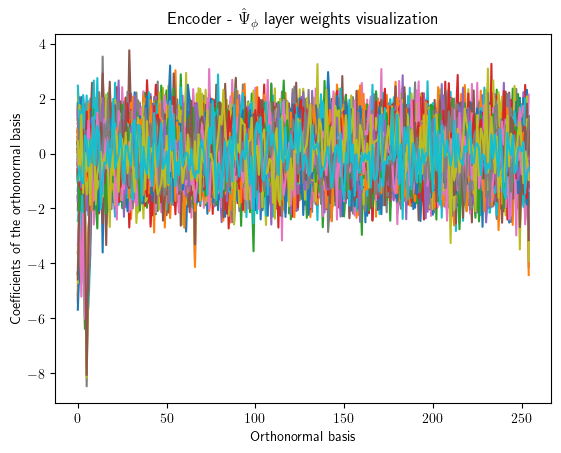

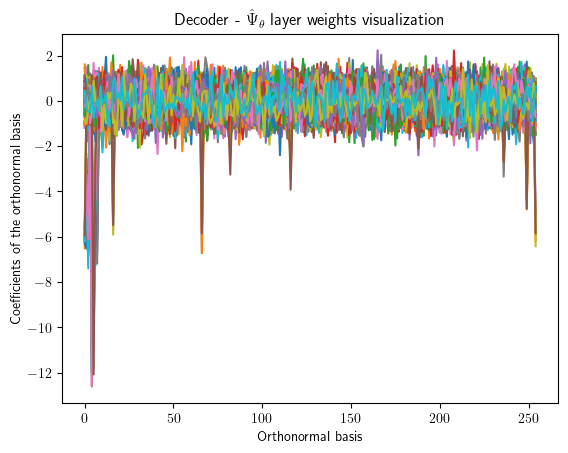

In [7]:
# Weights visualization of deterministic part estimated by both encoder and decoder for all samples excluding the bias (we disable saving option)
discard_bias = True
weights_visualization(encoder, decoder, [i for i in range(nb_samples)], discard_bias=discard_bias, saving=False, path=None, filename=None)

We can visually compare the extracted leakage models with the true leakage model $\Psi$.

To compute $\Psi$, we use $\texttt{orthonormal\_basis\_computation\_true\_coeffs}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).

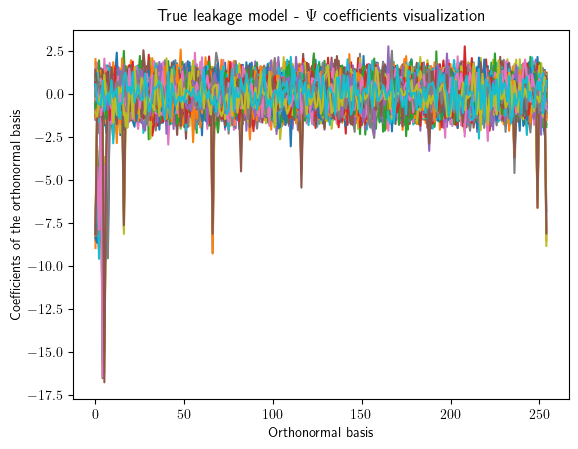

In [8]:
# Computation of an estimation of the real orthonormal basis coefficients
psi = orthonormal_basis_computation_true_coeffs(traces, targeted_variables, max_nb_monomials_interactions)

# Plot of the true leakage model for all samples excluding the bias
for i in range(psi.shape[0]):
    plt.plot(psi[i,int(discard_bias):])

plt.title(r'True leakage model - $\Psi$ coefficients visualization')
plt.xlabel('Orthonormal basis')
plt.ylabel('Coefficients of the orthonormal basis')
plt.show()

We can also compare more formally leakage models $\hat{\Psi}_\phi$ and $\hat{\Psi}_\theta$ extracted by the model with the true leakage model $\Psi$ by using mean squared error (MSE).

In [9]:
# Getting back from the encoder and decoder the weights i.e. estimated deterministic parts
psi_phi = encoder.get_layer('psi_layer_encoder').weights[0].numpy()
psi_phi = psi_phi.T
psi_theta = decoder.get_layer('psi_layer_decoder').weights[0].numpy()
psi_theta = psi_theta.T

# Computation of MSE 
psi_phi_difference = np.subtract(psi, psi_phi)
psi_theta_difference = np.subtract(psi, psi_theta)
psi_phi_mse = np.mean(np.square(psi_phi_difference))
psi_theta_mse = np.mean(np.square(psi_theta_difference))

print("MSE(Psi, Psi_phi) = %.5f" % psi_phi_mse)
print("MSE(Psi, Psi_theta) = %.5f" % psi_theta_mse)

MSE(Psi, Psi_phi) = 1.78282
MSE(Psi, Psi_theta) = 0.23591


Regarding $\boldsymbol{\Sigma}_\phi$, we can compute the approximation error for each sample.

In [10]:
# Getting back from the encoder the weights i.e. the inverse of the variance for each sample
encoder_inverse_variances = encoder.get_layer('z_mean').weights[0].numpy()
encoder_variances = 1/encoder_inverse_variances

# Computation of approximation errors
true_variances = sigmas**2
approx_errors = np.abs(np.subtract(true_variances,encoder_variances)/true_variances)
percent_errors = 100 * approx_errors

print("Mean of percent approximation errors: %.2f%%" % np.mean(percent_errors))

Mean of percent approximation errors: 3.42%


All the results obtained through this notebook are in line with those reported in Section 5.1.4.

We observe that cVAE-OSM is able to correctly extract leakage model and variance of traces, when training is carried out considering $N<D$. Indeed, we obtain a low MSE value for $\Psi_\phi$ and  $\Psi_\theta$ estimation and the average of percent approximation errors does not exceed $4\%$ for $\boldsymbol{\Sigma}_\phi$ estimation.

Consequently, this means that cVAE-OSM is able to overcome HDLSS/SSS problem.